# Random Forest Model

This notebook develops a Random Forest model for Telco Customer Churn prediction.

The data has already been cleaned, transformed, feature-engineered, and split into training and testing sets.

The main steps are:

1. Train a baseline Random Forest.
2. Evaluate the baseline model.
3. Tune the model using GridSearchCV.
4. Compare baseline and tuned results.
5. Analyze feature importance.
6. Save the final model.

## 1. Load the Prepared Train/Test Data

The preprocessing and feature selection have already been completed by the project.

The training and testing data are already prepared.

In this notebook, I will use the prepared data directly without doing preprocessing again.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

RANDOM_STATE = 42

sns.set_style("whitegrid")

X_train = pd.read_csv("../../../SplitData/X_train.csv")
X_test = pd.read_csv("../../../SplitData/X_test.csv")

y_train = pd.read_csv("../../../SplitData/y_train.csv").iloc[:, 0]
y_test = pd.read_csv("../../../SplitData/y_test.csv").iloc[:, 0]

print("Data loaded successfully.")

Data loaded successfully.


## 2. Check the Data

Before training the model, I check the shape of the training and testing data.

This confirms that the correct prepared data is being used.

In [2]:
print("Training target distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting target distribution:")
print(y_test.value_counts().sort_index())

Training target distribution:
Churn Label
0    4139
1    1495
Name: count, dtype: int64

Testing target distribution:
Churn Label
0    1035
1     374
Name: count, dtype: int64


## 4. Target Distribution Table

A simple table is used to clearly show the number of customers in each churn class.

In [3]:
target_table = pd.DataFrame({
    "Class": ["No Churn", "Churn"],
    "Training Count": [
        (y_train == 0).sum(),
        (y_train == 1).sum()
    ],
    "Testing Count": [
        (y_test == 0).sum(),
        (y_test == 1).sum()
    ]
})

display(target_table)

,Class,Training Count,Testing Count
0,No Churn,4139,1035
1,Churn,1495,374


## 5. Random Forest

Random Forest is a machine learning algorithm that combines many decision trees to make a prediction.

It is suitable for this project because the target is a classification problem and the data contains multiple customer features.

First, I will train a baseline Random Forest model.

In [4]:
baseline_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=RANDOM_STATE
)

baseline_rf.fit(X_train, y_train)

print("Baseline Random Forest trained successfully.")

Baseline Random Forest trained successfully.


## 6. Baseline Predictions

The trained baseline Random Forest is now used to predict churn for the test data.

These predictions will be used to evaluate the model.

In [5]:
y_pred_base = baseline_rf.predict(X_test)

print("Baseline predictions completed.")
print("First 10 predictions:")
print(y_pred_base[:10])

Baseline predictions completed.
First 10 predictions:
[0 0 0 0 0 0 1 1 0 1]


## 7. Baseline Model Evaluation

The baseline model is evaluated using accuracy, precision, recall and F1-score.

These metrics help us understand how well the model predicts customer churn.

In [6]:
baseline_accuracy = accuracy_score(y_test, y_pred_base)

baseline_precision = precision_score(
    y_test,
    y_pred_base,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    y_pred_base,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    y_pred_base,
    zero_division=0
)

print("Baseline Random Forest Results")
print("--------------------------------")
print("Accuracy :", round(baseline_accuracy, 4))
print("Precision:", round(baseline_precision, 4))
print("Recall   :", round(baseline_recall, 4))
print("F1-score :", round(baseline_f1, 4))

Baseline Random Forest Results
--------------------------------
Accuracy : 0.8396
Precision: 0.7483
Recall   : 0.5963
F1-score : 0.6637


## 8. Baseline Results Table

The evaluation results are presented in a simple table so they can be compared with the tuned Random Forest later.

In [7]:
baseline_results = pd.DataFrame({
    "Model": ["Baseline Random Forest"],
    "Accuracy": [baseline_accuracy],
    "Precision": [baseline_precision],
    "Recall": [baseline_recall],
    "F1-score": [baseline_f1]
})

display(baseline_results.round(4))

,Model,Accuracy,Precision,Recall,F1-score
0,Baseline Random Forest,0.8396,0.7483,0.5963,0.6637


## 9. Baseline Confusion Matrix

The confusion matrix shows how many customers were correctly and incorrectly classified as churn or no churn.

It helps us understand the types of prediction errors made by the model.

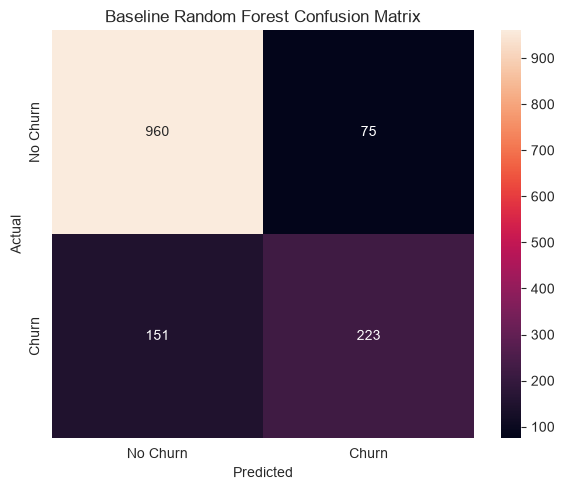

In [8]:
baseline_cm = confusion_matrix(y_test, y_pred_base)

plt.figure(figsize=(6, 5))

sns.heatmap(
    baseline_cm,
    annot=True,
    fmt="d",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Baseline Random Forest Confusion Matrix")

plt.tight_layout()
plt.show()

## 10. Baseline Classification Report

The classification report provides precision, recall and F1-score for each class.

This gives more detail about how the model performs for both churn and no-churn customers.

In [9]:
print(
    classification_report(
        y_test,
        y_pred_base,
        target_names=["No Churn", "Churn"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    No Churn       0.86      0.93      0.89      1035
       Churn       0.75      0.60      0.66       374

    accuracy                           0.84      1409
   macro avg       0.81      0.76      0.78      1409
weighted avg       0.83      0.84      0.83      1409



## 11. Hyperparameter Tuning

The baseline Random Forest uses one set of model settings.

Hyperparameter tuning tests different settings to find a better configuration.

GridSearchCV will test different combinations and select the combination with the best F1-score.

## 12. Define Random Forest Hyperparameters

The following Random Forest settings will be tested.

The purpose is to find which combination gives the best validation performance.

In [10]:
param_grid = {
    "n_estimators": [200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"]
}

print("Hyperparameter combinations defined.")

Hyperparameter combinations defined.


## 13. Cross-Validation

Five-fold Stratified Cross-Validation is used during tuning.

The training data is divided into five parts.

The model is trained and validated multiple times so that the performance is not based on only one split.

Stratification helps keep the churn class distribution similar across the folds.

In [11]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42

In [12]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

print("5-fold Stratified Cross-Validation created.")

5-fold Stratified Cross-Validation created.


## 14. Run GridSearchCV

GridSearchCV tests the different hyperparameter combinations.

F1-score is used as the scoring metric because the churn classes are imbalanced and both precision and recall are important.

In [13]:
# Small parameter grid
param_grid_small = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20],
    "min_samples_split": [2],
    "min_samples_leaf": [1],
    "max_features": ["sqrt"]
}

# Create Random Forest
rf_tuner = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_tuner,
    param_grid=param_grid_small,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    refit=True
)

# Start tuning
grid_search.fit(X_train, y_train)

print("GridSearchCV completed.")



GridSearchCV completed.


## 15. Best Hyperparameters

GridSearchCV selects the combination of hyperparameters that achieved the best average F1-score during cross-validation.

These are the selected settings for the tuned Random Forest.

In [14]:
print("Best Hyperparameters:")

for parameter, value in grid_search.best_params_.items():
    print(parameter, ":", value)

print(
    "Best Cross-Validation F1-score:",
    round(grid_search.best_score_, 4)
)

Best Hyperparameters:
max_depth : 10
max_features : sqrt
min_samples_leaf : 1
min_samples_split : 2
n_estimators : 200
Best Cross-Validation F1-score: 0.6777


## 16. Best Cross-Validation Score

The best cross-validation F1-score shows the average performance of the best parameter combination across the five validation folds.

In [15]:
print(
    "Best Cross-Validation F1-score:",
    round(grid_search.best_score_, 4)
)

Best Cross-Validation F1-score: 0.6777


## 17. Tuned Random Forest

The best model found by GridSearchCV is selected as the tuned Random Forest.

This model will now be evaluated on the test data.

In [16]:
tuned_rf = grid_search.best_estimator_

print("Tuned Random Forest selected.")

Tuned Random Forest selected.


## 18. Tuned Model Predictions

The tuned Random Forest is used to predict churn for the test data.

These predictions are compared with the actual test labels.

In [17]:
y_pred_tuned = tuned_rf.predict(X_test)

print("Tuned predictions completed.")
print("First 10 predictions:")
print(y_pred_tuned[:10])

Tuned predictions completed.
First 10 predictions:
[0 0 0 0 0 0 1 1 0 1]


## 19. Tuned Model Evaluation

The tuned Random Forest is evaluated using the same metrics as the baseline model.

Using the same metrics makes it possible to compare the two models fairly.

In [18]:
tuned_accuracy = accuracy_score(y_test, y_pred_tuned)

tuned_precision = precision_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)

tuned_recall = recall_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)

tuned_f1 = f1_score(
    y_test,
    y_pred_tuned,
    zero_division=0
)

print("Tuned Random Forest Results")
print("-----------------------------")
print("Accuracy :", round(tuned_accuracy, 4))
print("Precision:", round(tuned_precision, 4))
print("Recall   :", round(tuned_recall, 4))
print("F1-score :", round(tuned_f1, 4))

Tuned Random Forest Results
-----------------------------
Accuracy : 0.8439
Precision: 0.7484
Recall   : 0.6203
F1-score : 0.6784


## 20. Tuned Results Table

The tuned model results are shown in a table using the same evaluation metrics as the baseline model.

In [19]:
tuned_results = pd.DataFrame({
    "Model": ["Tuned Random Forest"],
    "Accuracy": [tuned_accuracy],
    "Precision": [tuned_precision],
    "Recall": [tuned_recall],
    "F1-score": [tuned_f1]
})

display(tuned_results.round(4))

,Model,Accuracy,Precision,Recall,F1-score
0,Tuned Random Forest,0.8439,0.7484,0.6203,0.6784


## 21. Baseline vs Tuned Comparison

The baseline and tuned Random Forest models are compared using the same evaluation metrics.

This helps determine whether hyperparameter tuning improved the model.

In [20]:
comparison_df = pd.DataFrame({
    "Accuracy": [
        baseline_accuracy,
        tuned_accuracy
    ],
    "Precision": [
        baseline_precision,
        tuned_precision
    ],
    "Recall": [
        baseline_recall,
        tuned_recall
    ],
    "F1-score": [
        baseline_f1,
        tuned_f1
    ]
}, index=[
    "Baseline Random Forest",
    "Tuned Random Forest"
])

display(comparison_df.round(4))

,Accuracy,Precision,Recall,F1-score
Baseline Random Forest,0.8396,0.7483,0.5963,0.6637
Tuned Random Forest,0.8439,0.7484,0.6203,0.6784


## 22. Baseline vs Tuned Graph

The following graph visually compares the baseline and tuned Random Forest models.

This makes it easier to see whether tuning improved the evaluation metrics.

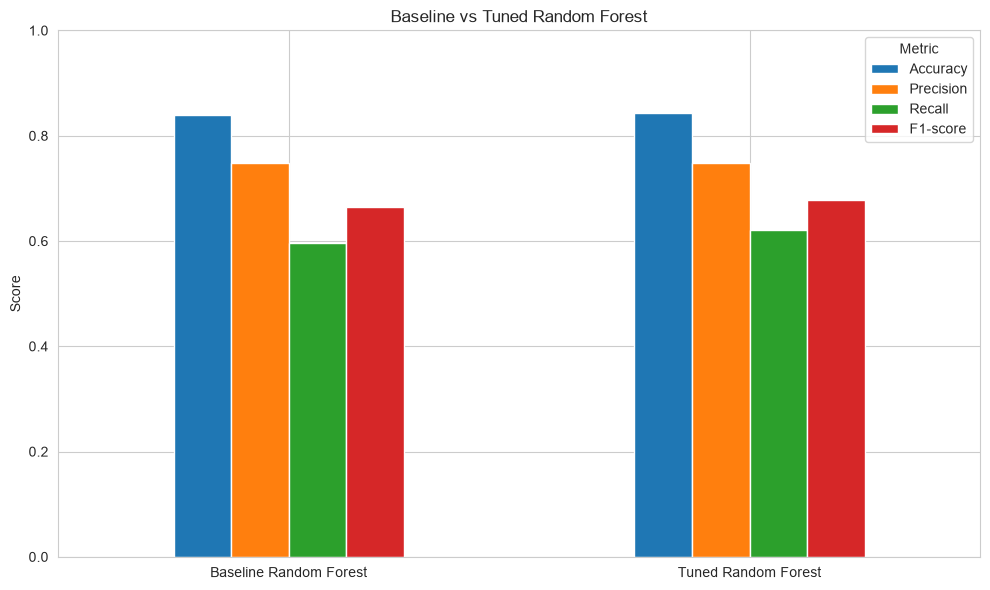

In [21]:
comparison_df.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Baseline vs Tuned Random Forest")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")

plt.tight_layout()
plt.show()

## 23. Tuned Confusion Matrix

The confusion matrix is created for the tuned Random Forest.

It shows the correct and incorrect churn predictions made by the final tuned model.

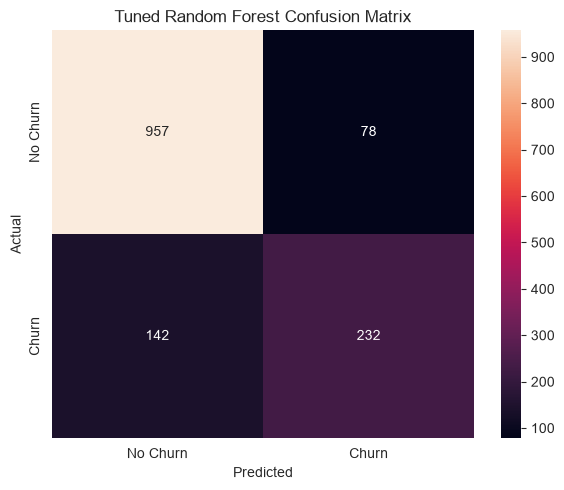

In [22]:
tuned_cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 5))

sns.heatmap(
    tuned_cm,
    annot=True,
    fmt="d",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned Random Forest Confusion Matrix")

plt.tight_layout()
plt.show()

## 24. Tuned Classification Report

The classification report provides detailed precision, recall and F1-score results for both classes.

In [23]:
print(
    classification_report(
        y_test,
        y_pred_tuned,
        target_names=["No Churn", "Churn"],
        zero_division=0
    )
)

              precision    recall  f1-score   support

    No Churn       0.87      0.92      0.90      1035
       Churn       0.75      0.62      0.68       374

    accuracy                           0.84      1409
   macro avg       0.81      0.77      0.79      1409
weighted avg       0.84      0.84      0.84      1409



## 25. F1-score Improvement

The F1-score of the baseline and tuned models is compared.

This helps us see whether tuning improved the main metric used during GridSearchCV.

In [24]:
f1_comparison = pd.DataFrame({
    "Model": [
        "Baseline Random Forest",
        "Tuned Random Forest"
    ],
    "F1-score": [
        baseline_f1,
        tuned_f1
    ]
})

display(f1_comparison.round(4))

,Model,F1-score
0,Baseline Random Forest,0.6637
1,Tuned Random Forest,0.6784


## 26. Tuning Result

The baseline and tuned models are compared based on their test results.

If the tuned model has a higher F1-score, tuning improved the model.

If the tuned model does not have a higher F1-score, the tuning process did not improve the test performance.

In [25]:
if tuned_f1 > baseline_f1:
    print("Tuning improved the test F1-score.")
elif tuned_f1 < baseline_f1:
    print("Tuning did not improve the test F1-score.")
else:
    print("The baseline and tuned models have the same test F1-score.")

Tuning improved the test F1-score.


## 27. Feature Importance

Random Forest provides feature importance values.

These values show which features were more useful for the model when making predictions.

Feature importance shows predictive importance and does not prove that a feature causes churn.

In [26]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": tuned_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

display(feature_importance.head(10))

,Feature,Importance
45,cat__Contract_Month-to-Month,0.110392
3,num__Tenure in Months,0.102168
2,num__Number of Referrals,0.074567
6,num__Monthly Charge,0.066269
0,num__Age,0.053335
47,cat__Contract_Two Year,0.045812
53,cat__Tenure Group_0-12,0.040123
5,num__Avg Monthly GB Download,0.039849
27,cat__Internet Type_Fiber Optic,0.038867
9,num__CLTV,0.034499


## 28. Top 10 Important Features

The top 10 features are displayed as a bar chart.

This provides a visual view of which features were most important to the Random Forest model.

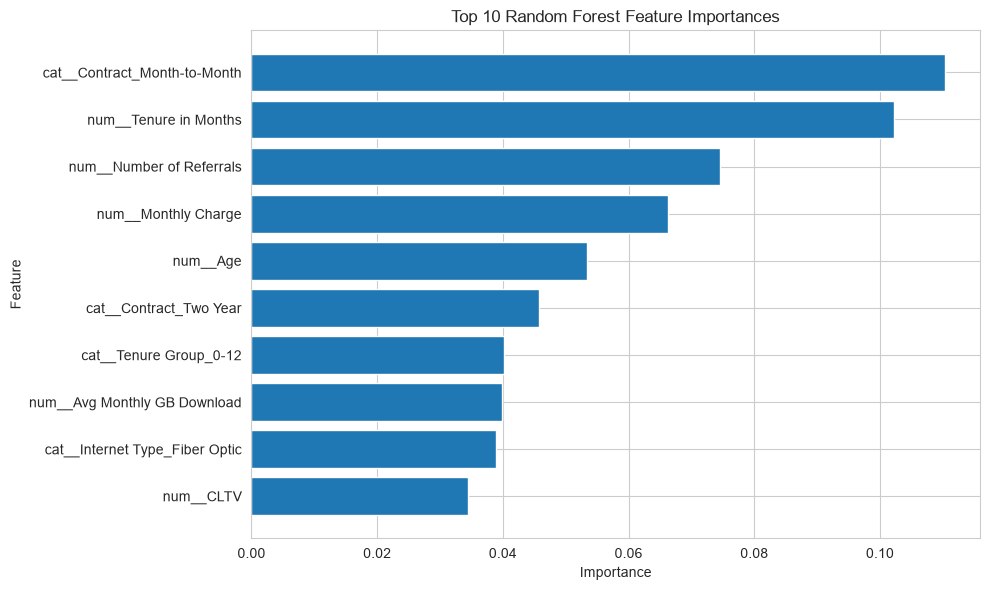

In [27]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

## 29. Save the Final Random Forest Model

The tuned Random Forest is saved as a separate model file.

This saved model can later be used by the project backend to make predictions.

In [28]:
model_path = "../../../models/random_forest_final.pkl"

joblib.dump(tuned_rf, model_path)

print("Model saved successfully.")
print("Path:", model_path)

Model saved successfully.
Path: ../../../models/random_forest_final.pkl


## 30. Verify the Saved Model

The saved model is loaded again to confirm that the model file works correctly.

A few test predictions are made using the loaded model.

In [29]:
loaded_model = joblib.load(model_path)

loaded_predictions = loaded_model.predict(
    X_test.head(3)
)

print("Saved model loaded successfully.")
print("Predictions for first 3 test rows:")
print(loaded_predictions.tolist())

Saved model loaded successfully.
Predictions for first 3 test rows:
[0, 0, 0]


## 31. Random Forest Summary

The Random Forest model was trained using the prepared project data.

A baseline model was first created and evaluated.

GridSearchCV was then used to tune the Random Forest hyperparameters.

The baseline and tuned models were compared using accuracy, precision, recall and F1-score.

The feature importance of the tuned model was also analysed.

The final tuned Random Forest was saved for use by the project.

## 32. Results for Group Model Comparison

The Random Forest results will be provided to the group so they can be compared with Logistic Regression, Decision Tree and XGBoost.

The final model will be selected by comparing the performance of all four algorithms.

In [30]:
group_results = pd.DataFrame({
    "Model": ["Random Forest"],
    "Accuracy": [tuned_accuracy],
    "Precision": [tuned_precision],
    "Recall": [tuned_recall],
    "F1-score": [tuned_f1]
})

display(group_results.round(4))

,Model,Accuracy,Precision,Recall,F1-score
0,Random Forest,0.8439,0.7484,0.6203,0.6784
